---
# 🎯 BLOQUE 3 — Ejercicio Final: Todo junto

## El reto de hoy: Predictor de precios de vivienda en Bogotá

Vamos a construir un modelo completo que, dado el área de un apartamento, prediga su precio. Usaremos todo lo que aprendimos hoy:

- **Álgebra lineal:** El modelo es `precio = m × área + b` (operación lineal)
- **Función de pérdida:** MSE para medir el error
- **Descenso del gradiente:** Para encontrar los mejores valores de m y b
- **Normalización:** Preprocesar los datos para que el GD funcione correctamente

---

### ¿Por qué normalizar los datos antes del Descenso del Gradiente?

Esta es una de las preguntas más frecuentes y más importantes:

```
Sin normalización:
  área = [40, 80, 120, 200]     (escala: decenas)
  precio = [122, 194, 266, 410]  (escala: cientos)

  → Los gradientes respecto a m y b tienen escalas muy diferentes
  → El learning rate que funciona para m no funciona para b
  → El modelo converge muy lento o diverge
```

```
Con normalización (Z-score):
  área_norm = (área - media) / desviación_estándar
  → Todos los valores quedan en escala similar (media=0, std=1)
  → Los gradientes son comparables
  → El descenso del gradiente converge mucho más rápido ✅
```

> 💡 **Regla de oro:** **Siempre normaliza tus datos antes de entrenar**. Scikit-learn tiene `StandardScaler` para esto. En redes neuronales, las capas `BatchNorm` hacen algo similar durante el entrenamiento.

---

### Conexión con el mundo real

Este ejercicio es una versión simplificada de lo que hacen plataformas como Finca Raíz o Properati para estimar precios. En la realidad tienen cientos de variables (ubicación, estrato, parqueadero, año de construcción...), pero el principio es el mismo: minimizar el error de predicción ajustando parámetros con Descenso del Gradiente.

📝 Tarea para la próxima clase

1. ✅ **Ejecutar todo el notebook** sin errores (asegúrate de entender cada celda)
2. ✅ **Experimento del learning rate:** Modifica el ejercicio final cambiando α a 0.001, 0.5 y 1.5. Observa qué pasa con la curva de aprendizaje y escribe tus conclusiones
3. ✅ **Investiga:** ¿Qué diferencia hay entre el GD que implementamos y el SGD (Stochastic Gradient Descent)? ¿Por qué el SGD es más usado en la práctica?
4. 🚀 **Desafío extra:** Modifica el ejercicio final para incluir una segunda variable (`num_habitaciones`) y entrena un modelo de regresión múltiple con 3 parámetros: m₁, m₂ y b


=== Predictor de Precios de Vivienda - Bogotá ===
Parámetros aprendidos:
  Precio = 1.76 × Área + 54.74
Modelo real (ground truth):
  Precio = 1.80 × Área + 50.00
MSE final: 0.030052 (en espacio normalizado)

Predicciones para nuevas propiedades:
  Casa de  60m² → Precio estimado: $  160.5M COP
  Casa de  90m² → Precio estimado: $  213.3M COP
  Casa de 120m² → Precio estimado: $  266.2M COP
  Casa de 150m² → Precio estimado: $  319.0M COP
  Casa de 180m² → Precio estimado: $  371.9M COP


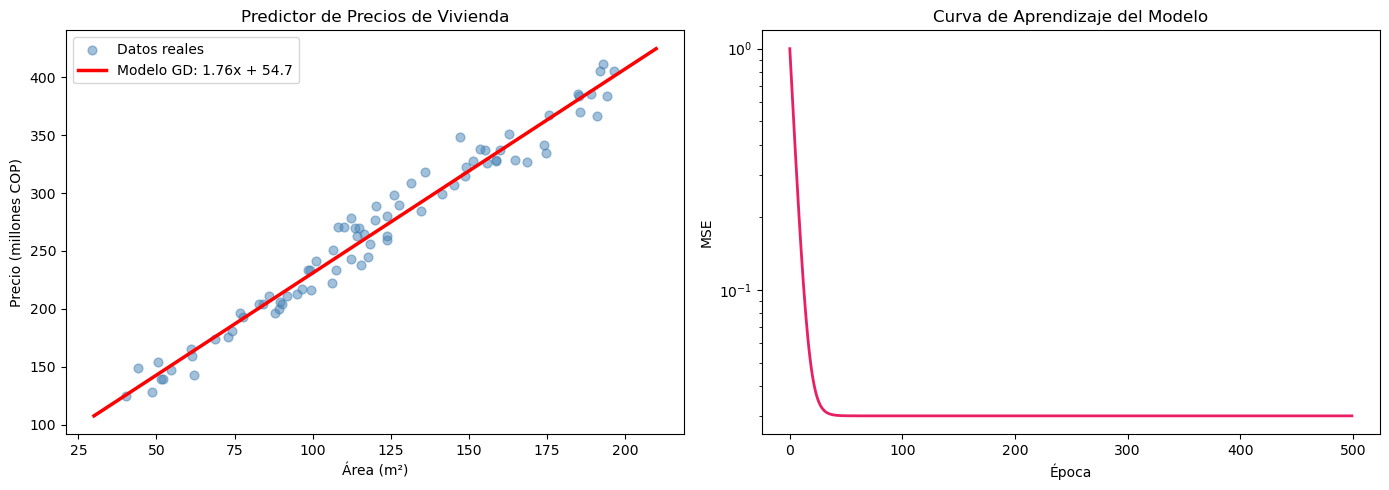

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO FINAL: Predictor de precios de vivienda
# Dataset: área (m²) → precio (millones COP)
# ════════════════════════════════════════════════════════════════════════════

np.random.seed(7)

# Dataset de 80 casas en Bogotá
area = np.random.uniform(40, 200, 80)                  # área entre 40 y 200 m²
precio_real = 1.8 * area + 50 + np.random.randn(80) * 15  # Precio real + ruido

# Normalización (IMPORTANTE: siempre normalizar antes de GD)
# Sin normalización, los gradientes pueden ser muy grandes y el modelo diverge
area_media   = area.mean()
area_std     = area.std()
area_norm    = (area - area_media) / area_std  # Z-score normalization

precio_media = precio_real.mean()
precio_std   = precio_real.std()
precio_norm  = (precio_real - precio_media) / precio_std

# ─── ENTRENAMIENTO CON GD ────────────────────────────────────────────────────
m, b   = 0.0, 0.0
alpha  = 0.05
epocas = 500
n      = len(area_norm)
historial = []

for epoch in range(epocas):
    y_pred    = m * area_norm + b                          # Forward pass
    error     = y_pred - precio_norm                       # Diferencia
    mse_val   = np.mean(error ** 2)                        # Pérdida
    historial.append(mse_val)
    grad_m    = (2/n) * np.dot(error, area_norm)           # Gradiente de m
    grad_b    = (2/n) * np.sum(error)                      # Gradiente de b
    m        -= alpha * grad_m                             # Actualizar m
    b        -= alpha * grad_b                             # Actualizar b

# Des-normalizar los parámetros para interpretar en unidades originales
m_real = m * (precio_std / area_std)
b_real = precio_media + b * precio_std - m_real * area_media

print('=== Predictor de Precios de Vivienda - Bogotá ===')
print(f'Parámetros aprendidos:')
print(f'  Precio = {m_real:.2f} × Área + {b_real:.2f}')
print(f'Modelo real (ground truth):')
print(f'  Precio = 1.80 × Área + 50.00')
print(f'MSE final: {historial[-1]:.6f} (en espacio normalizado)')
print()

# Predicciones para casas nuevas
casas_nuevas = np.array([60, 90, 120, 150, 180])
print('Predicciones para nuevas propiedades:')
for area_casa in casas_nuevas:
    precio_pred = m_real * area_casa + b_real
    print(f'  Casa de {area_casa:>3}m² → Precio estimado: ${precio_pred:>7.1f}M COP')

# ─── VISUALIZACIÓN FINAL ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo final vs datos reales
axes[0].scatter(area, precio_real, alpha=0.5, color='steelblue', s=40, label='Datos reales')
x_line = np.linspace(30, 210, 200)
axes[0].plot(x_line, m_real * x_line + b_real, 'r-', linewidth=2.5, 
             label=f'Modelo GD: {m_real:.2f}x + {b_real:.1f}')
axes[0].set_xlabel('Área (m²)')
axes[0].set_ylabel('Precio (millones COP)')
axes[0].set_title('Predictor de Precios de Vivienda')
axes[0].legend()

# Curva de aprendizaje
axes[1].plot(historial, '#E91E63', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MSE')
axes[1].set_title('Curva de Aprendizaje del Modelo')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()